

# Partial Dependence Regression
### OPIM 5512 — Applied Data Science · Module2

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5512-notebooks/blob/main/Module2/1_PartialDependence_Regression.ipynb)

*Run me top to bottom — **Runtime → Run all**. Data loads from a stable link, so there's nothing to upload.*

# Partial Dependence Plots (regression)
**Dr. Dave Wanik - OPIM 5512: Data Science Using Python - University of Connecticut**

---------------------------------

Our model fit and we got results - we saw what the important variables were - *but **how** did the model use the variables?*



In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# to get rid of annoying future warnings...

In [ ]:
!pip install pulp # for partial dependence plots!
!pip install pycebox
from pycebox.ice import ice, ice_plot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 39.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pycebox: filename=pycebox-0.0.1-py3-none-any.whl size=3624 sha256=89325a9b674a0e66144a893d3027bce380858483f042259196c8e5717ae1ead9
  Stored in directory: /root/.cache/pip/wheels/b7/eb/8b/a6716f12a629b3dff6c3de159e42015252cb88ddafbbf9c668
Successfully built pycebox


## Getting started
Import modules, mount Drive, read in the data, check data types and missing values. You may also do some light EDA prior to modeling.

Notice how we are using the same functions over and over again... it really is like following a recipe.


In [ ]:
# import modules we need for EDA and wrangling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# these functions are useful for splitting and normalization
from sklearn.preprocessing import  MinMaxScaler
from sklearn.model_selection import train_test_split

# import other functions we'll need for regression modeling
from sklearn.linear_model import LinearRegression # LR
from sklearn.tree import DecisionTreeRegressor # DTR
from sklearn.ensemble import RandomForestRegressor # RFR
from sklearn.ensemble import GradientBoostingRegressor #GBR

# regression error metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [ ]:
# Load dataset
# we will use Gdown to load our Boston Housing dataset
# https://drive.google.com/file/d/1a0aNGSFWB-pf5ut1NsjE5ECIsbHHoAwI/view?usp=sharing
!gdown --id 1a0aNGSFWB-pf5ut1NsjE5ECIsbHHoAwI

# look left! it downloaded a local copy of 'BostonHousing.csv'

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1a0aNGSFWB-pf5ut1NsjE5ECIsbHHoAwI
To: /content/BostonHousing.csv
100% 35.2k/35.2k [00:00<00:00, 46.2MB/s]


In [ ]:
# read in the data
df = pd.read_csv('BostonHousing.csv')

In [ ]:
# data type, shape and columns

print("This is the shape :\n", df.shape, '\n') # escape characters are fun! \n adds a return line
print("These are the column names: \n", df.columns, '\n') # helps keep things nice and clean
print("These are the data types: \n", df.dtypes)

# right away you see this 'valid' column is an 'object', which means it's a string
# AKA something you can't do math on... look at the head and see what's going on
# in that column. ALL OTHER DATA IS NUMERIC (float64)
# this is a good quiz question... ;)

print("\nThis is the head:") # see how I can pop that \n anywhere?
df.head()   # also note how much stuff I have pasted in ONE CELL...
            # now you are cooking with gas!

# the head confirms to use that the valid column is some type of time/date stamp
# we need to stop what we are doing and take care of this NOW!

This is the shape :
 (506, 14) 

These are the column names: 
 Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object') 

These are the data types: 
 crim       float64
zn         float64
indus      float64
chas         int64
nox        float64
rm         float64
age        float64
dis        float64
rad          int64
tax          int64
ptratio    float64
b          float64
lstat      float64
medv       float64
dtype: object

This is the head:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
# here's another cool way to get a lot of this info AND MORE
df.info() # gives you missing values report too - this is nice complete data

# data types, shape, missing values per columm.... pandas rocks...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


## Data splitting
Subset your data into X features and Y target variable for modeling. Convert X and Y to numpy arrays. Then use train_test_split for data splitting (80/20 is very common); don't forget random seed and shuffle.

In [ ]:
# the target variable is Y
# we know that this is 'medv'
Y = df['medv']
print(Y.shape) # a single column with 506 rows

(506,)


In [ ]:
# everything else is X
# so just drop 'medv' and you are done
X = df.drop('medv', axis=1)
print(X.shape) # note that we have gone from 14 to 13 columns, this is good! 506 rows.

(506, 13)


In [ ]:
# commented out for now, but later, let's try re-running
# by only using a few columns (from feature importance plots)
# X = df[['lstat', 'crim', 'dis', 'rad']]
# X.shape # only 4 columns

In [ ]:
# now, split the data in ONE LINE OF CODE
# notice how we are assigning four different variables at once
# this makes it really clean

# be careful of capital vs. lowercase X and Y, you might get an error...
# notice the 80/20 split we perform

X_train, X_test, y_train, y_test = train_test_split(X, Y,
                                                    test_size = 0.2,
                                                    shuffle = True,
                                                    random_state = 42)

In [ ]:
# check your work - does the shape match what you think it should be?
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(404, 13) (102, 13) (404,) (102,)


In [ ]:
# convert these all to numpy arrays
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

## Min/Max Scaling
This will ensure all of your X data is between 0 (min) and 1 (max). You will use fit_transform() on the train data first, then fit on the test data. If you don't do this step after splitting, you will have data leakage.

Only scale the X data, not the Y data!

Do yourself a favor and just overwrite X_train and X_test when standardizing, as I do below. Min/max scaling requires that the data are numpy arrays and all numeric data.


**Like this example:**
```
import numpy as np
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
```


In [ ]:
# you probably have already imported the MinMaxScale at the top of your script
# you should convert to numpy array before scaling
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# if you wanted to run summary stats on these to check the range,
# you would need to convert to a pandas dataframe.
tmp = pd.DataFrame(X_train)
tmp.describe() # notice how all the max values are 1, all min values are 0.

,0,1,2,3,4,5,6,7,8,9,10,11,12
count,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000,404.000000
mean,0.040465,0.115693,0.379446,0.071782,0.352848,0.498859,0.676173,0.243577,0.363323,0.414184,0.608332,0.897570,0.296009
std,0.099757,0.231525,0.255356,0.258447,0.242190,0.144285,0.288310,0.193802,0.373466,0.317123,0.237096,0.230890,0.196203
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000814,0.000000,0.162593,0.000000,0.137860,0.412345,0.439238,0.087140,0.130435,0.175573,0.446809,0.945969,0.139142
50%,0.002836,0.000000,0.289630,0.000000,0.314815,0.477324,0.770340,0.186066,0.173913,0.272901,0.648936,0.985892,0.253725
75%,0.035900,0.200000,0.642963,0.000000,0.506173,0.564114,0.934604,0.388400,0.478261,0.914122,0.808511,0.997113,0.404042
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Fit The Model
Fit the model and make new variables to save your train and test predictions. Make sure you are using the appropriate regression or classification model.

Notice how we're using the same training data and test data for each model - this is critical!

Also note that in many StackOverflow examples, folks don't use 'DTR' or 'LR' as variable names for their models - instead, they often use 'clf' which stands for classifier. Helps you abstract what's going on.

### Linear Regression

In [ ]:
# make a variable to store the general model
LR = LinearRegression()
# fit the model - one line of code
LR = LR.fit(X_train, y_train)

In [ ]:
# store the predictions
train_preds_LR = LR.predict(X_train)
test_preds_LR = LR.predict(X_test)

### DTR

Check out the model documentation:

**DTR Model Documentation:** https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html


Some extra content to think about...

**Link:** https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html

**Link:** https://scikit-learn.org/stable/modules/tree.html

In [ ]:
# make a variable to store the general model
# you can accept all of the defaults...
DTR = DecisionTreeRegressor()
# or start to 'tinker' :) this is called hyperparameter tuning
# DTR = DecisionTreeRegressor(min_samples_split=15) # make this bigger and the tree will shrink!

# fit the model - one line of code
DTR = DTR.fit(X_train, y_train)

In [ ]:
# store the predictions
train_preds_DTR = DTR.predict(X_train)
test_preds_DTR = DTR.predict(X_test)

In [ ]:
# show the tree
# link: https://www.datacamp.com/community/tutorials/decision-tree-classification-python
from sklearn.tree import export_graphviz
# from sklearn.externals.six import StringIO
from six import StringIO
from IPython.display import Image
import pydotplus

dot_data = StringIO()
export_graphviz(DTR, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

# hard to see, but that's OK!
# we will learn about partial depenence
# and feature importance with is way easier to see than this

# for now, just appreciate how awesome this looks!
# double click and you can see

Output hidden; open in https://colab.research.google.com to view.

### RFR
Random Forest Regressor

In [ ]:
# make a variable to store the general model
# you can accept all of the defaults...
RFR = GradientBoostingRegressor()
# or start to 'tinker' :) this is called hyperparameter tuning
# DTR = DecisionTreeRegressor(min_samples_split=15) # make this bigger and the tree will shrink!

# fit the model - one line of code
RFR = RFR.fit(X_train, y_train)

In [ ]:
# store the predictions
train_preds_RFR = RFR.predict(X_train)
test_preds_RFR = RFR.predict(X_test)

## Evaluate the Model
Look at the appropriate error metrics depending on the problem you are solving.

For a regression problem, look at the R2, MAE and MSE; then make a scatterplot of actual vs. predicted values with nice labels and titles.

For a classification problem, create the classification report (gives a confusion matrix and useful metrics in one line of code).

See how we are just tacking on a suffix like '_LR' or '_DTR' on the end of things? Keep your code clean and you can just copy paste. Same stuff as before, but we need to be organized since we are introducing more models.

## R2
Out of all of these, random forest is the most believable! Did not memorize the training data and has consistent results between train and test results. In practice - we only really care about the test results.

In [ ]:
# this is a regression problem, and there are three metrics to look at.
# 1) R2 value - for Linear Regression
print("This is train R2 (LR):", r2_score(y_train, train_preds_LR)) # train
print("This is test R2 (LR):", r2_score(y_test, test_preds_LR)) # test

# 1) R2 value - for Decision Tree Regression
print("This is train R2 (DTR):", r2_score(y_train, train_preds_DTR)) # train
print("This is test R2 (DTR):", r2_score(y_test, test_preds_DTR)) # test

# 1) R2 value - for Random Forest Regression
print("This is train R2 (RFR):", r2_score(y_train, train_preds_RFR)) # train
print("This is test R2 (RFR):", r2_score(y_test, test_preds_RFR)) # test

This is train R2 (LR): 0.7508856358979673
This is test R2 (LR): 0.6687594935356322
This is train R2 (DTR): 1.0
This is test R2 (DTR): 0.6953935796870703
This is train R2 (RFR): 0.9800300447996301
This is test R2 (RFR): 0.9139837584630994


## MAE
Again, RFR is the champ here - best test results!

In [ ]:
# 2) mae - for Linear Regression
trainMAE_LR = mean_absolute_error(y_train, train_preds_LR)
print("This is trainMAE (LR):", trainMAE_LR) # train
testMAE_LR = mean_absolute_error(y_test, test_preds_LR)
print("This is testMAE (LR):", testMAE_LR) # test

# 2) mae - for DT Regression
trainMAE_DTR = mean_absolute_error(y_train, train_preds_DTR)
print("This is trainMAE (DTR):", trainMAE_DTR) # train
testMAE_DTR = mean_absolute_error(y_test, test_preds_DTR)
print("This is testMAE (DTR):", testMAE_DTR) # test

# 2) mae - for RF Regression
trainMAE_RFR = mean_absolute_error(y_train, train_preds_RFR)
print("This is trainMAE (RFR):", trainMAE_RFR) # train
testMAE_RFR = mean_absolute_error(y_test, test_preds_RFR)
print("This is testMAE (RFR):", testMAE_RFR) # test

This is trainMAE (LR): 3.314771626783231
This is testMAE (LR): 3.189091965887846
This is trainMAE (DTR): 0.0
This is testMAE (DTR): 2.6813725490196085
This is trainMAE (RFR): 1.0438163652602068
This is testMAE (RFR): 1.925288583962113


## MSE
If you see an MSE of 0, this means a perfect prediction - this should NEVER happen... there should always be at least a little bit of error in your train results, otherwise you are OVERFITTING. You need to play with the hyperparameters (we will do this in future weeks).

In [ ]:
# 3) mse
trainMSE_LR = mean_squared_error(y_train, train_preds_LR)
print("This is trainMSE (LR):", trainMSE_LR)
testMSE_LR = mean_squared_error(y_test, test_preds_LR)
print("This is testMSE (LR):", testMSE_LR)

# 3) mse
trainMSE_DTR = mean_squared_error(y_train, train_preds_DTR)
print("This is trainMSE (DTR):", trainMSE_DTR)
testMSE_DTR = mean_squared_error(y_test, test_preds_DTR)
print("This is testMSE (DTR):", testMSE_DTR)

# 3) mse
trainMSE_RFR = mean_squared_error(y_train, train_preds_RFR)
print("This is trainMSE (RFR):", trainMSE_RFR)
testMSE_RFR = mean_squared_error(y_test, test_preds_RFR)
print("This is testMSE (RFR):", testMSE_RFR)

This is trainMSE (LR): 21.641412753226312
This is testMSE (LR): 24.291119474973502
This is trainMSE (DTR): 0.0
This is testMSE (DTR): 22.337941176470586
This is trainMSE (RFR): 1.7348579826478066
This is testMSE (RFR): 6.307896405133035


## Sub-Plots
Way cleaner! Try doing the plots side-by-side.

### LR Results

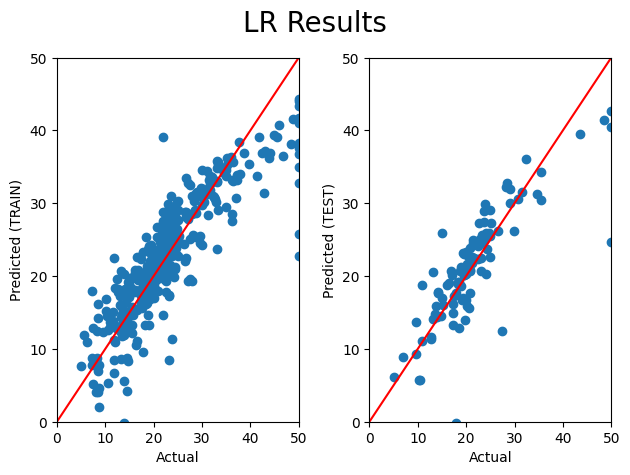

In [ ]:
# specify the dimensions
fig, axes = plt.subplots(1,2) # 1 row, 2 columns

# fig limits


# add a main title across top
fig.suptitle("LR Results", fontsize=20)

# this makes the individual subplots
axes[0].scatter(x=y_train, y=train_preds_LR) #first row, first entry (left top)
axes[0].set_xlabel("Actual", fontsize=10)
axes[0].set_ylabel("Predicted (TRAIN)",  fontsize=10)
# set plot limits
axes[0].set_xlim(0,50)
axes[0].set_ylim(0,50)
# add 45 degree line to left panel
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')


axes[1].scatter(x=y_test, y=test_preds_LR) # first row, second entry (right top)
axes[1].set_xlabel("Actual", fontsize=10)
axes[1].set_ylabel("Predicted (TEST)",  fontsize=10)
# set plot limits
axes[1].set_xlim(0,50)
axes[1].set_ylim(0,50)
# add 45 degree line to right panel
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# tight layout
fig.tight_layout()

# scooch it down
# link: https://stackoverflow.com/questions/7066121/how-to-set-a-single-main-title-above-all-the-subplots-with-pyplot
fig.subplots_adjust(top=0.88)

# show the plot
plt.show()

**Figure 1:** Actual vs. predicted for LR model by partition.

### DTR Results

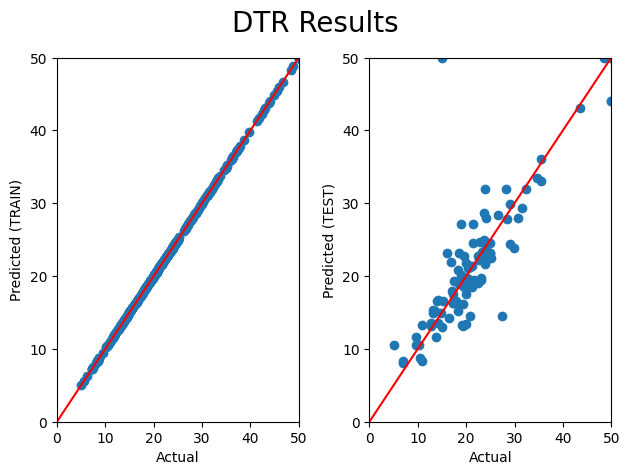

In [ ]:
# specify the dimensions
fig, axes = plt.subplots(1,2) # 1 row, 2 columns

# fig limits


# add a main title across top
fig.suptitle("DTR Results", fontsize=20)

# this makes the individual subplots
axes[0].scatter(x=y_train, y=train_preds_DTR) #first row, first entry (left top)
axes[0].set_xlabel("Actual", fontsize=10)
axes[0].set_ylabel("Predicted (TRAIN)",  fontsize=10)
# set plot limits
axes[0].set_xlim(0,50)
axes[0].set_ylim(0,50)
# add 45 degree line to left panel
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')


axes[1].scatter(x=y_test, y=test_preds_DTR) # first row, second entry (right top)
axes[1].set_xlabel("Actual", fontsize=10)
axes[1].set_ylabel("Predicted (TEST)",  fontsize=10)
# set plot limits
axes[1].set_xlim(0,50)
axes[1].set_ylim(0,50)
# add 45 degree line to right panel
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# tight layout
fig.tight_layout()

# scooch it down
# link: https://stackoverflow.com/questions/7066121/how-to-set-a-single-main-title-above-all-the-subplots-with-pyplot
fig.subplots_adjust(top=0.88)

# show the plot
plt.show()

**Figure 2:** Actual vs. predicted for DTR model by partition. Note the overfitting.

### RFR Results

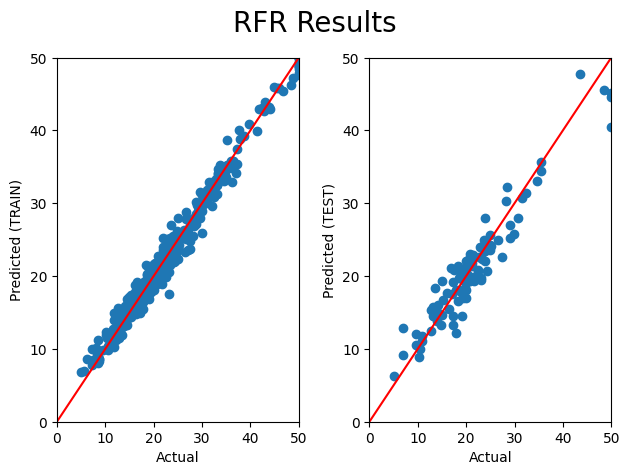

In [ ]:
# specify the dimensions
fig, axes = plt.subplots(1,2) # 1 row, 2 columns

# fig limits


# add a main title across top
fig.suptitle("RFR Results", fontsize=20)

# this makes the individual subplots
axes[0].scatter(x=y_train, y=train_preds_RFR) #first row, first entry (left top)
axes[0].set_xlabel("Actual", fontsize=10)
axes[0].set_ylabel("Predicted (TRAIN)",  fontsize=10)
# set plot limits
axes[0].set_xlim(0,50)
axes[0].set_ylim(0,50)
# add 45 degree line to left panel
x = np.linspace(*axes[0].get_xlim())
axes[0].plot(x, x, color='red')


axes[1].scatter(x=y_test, y=test_preds_RFR) # first row, second entry (right top)
axes[1].set_xlabel("Actual", fontsize=10)
axes[1].set_ylabel("Predicted (TEST)",  fontsize=10)
# set plot limits
axes[1].set_xlim(0,50)
axes[1].set_ylim(0,50)
# add 45 degree line to right panel
x = np.linspace(*axes[1].get_xlim())
axes[1].plot(x, x, color='red')

# tight layout
fig.tight_layout()

# scooch it down
# link: https://stackoverflow.com/questions/7066121/how-to-set-a-single-main-title-above-all-the-subplots-with-pyplot
fig.subplots_adjust(top=0.88)

# show the plot
plt.show()

**Figure 3:** Actual vs. predicted for RFR model by partition.

## Feature Importance
Each model has a different flavor - since each model treats the data differently, this means that different variables can affect the prediction!

Link: https://scikit-learn.org/stable/modules/permutation_importance.html

### RFR

/tmp/ipython-input-1219831324.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(result.importances[perm_sorted_idx].T, vert=False,


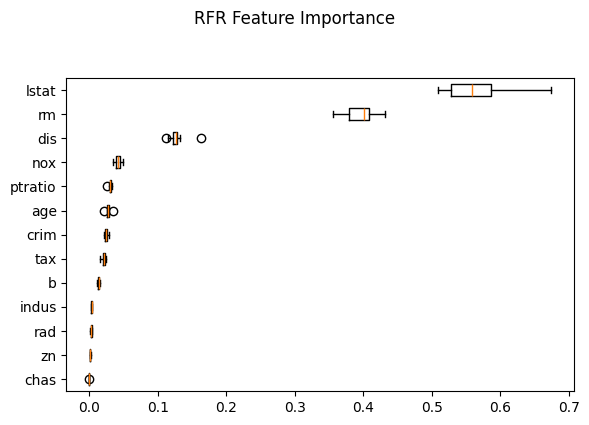

In [ ]:
from sklearn.inspection import permutation_importance

# let's make this repeatable! all you need to do is assign
# a model object to clf!

clf = RFR # just update the title!

result = permutation_importance(clf, X_train, y_train, n_repeats=10,
                                random_state=42)
perm_sorted_idx = result.importances_mean.argsort()

tree_importance_sorted_idx = np.argsort(clf.feature_importances_)
tree_indices = np.arange(0, len(clf.feature_importances_)) + 0.5

fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))
ax1.boxplot(result.importances[perm_sorted_idx].T, vert=False,
            labels=X.columns[perm_sorted_idx])
fig.suptitle('RFR Feature Importance', y=1.05)
fig.tight_layout()
plt.show()

**Figure 4:** Feature importance for RFR model.

### DTR

/tmp/ipython-input-3250355896.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(result.importances[perm_sorted_idx].T, vert=False,


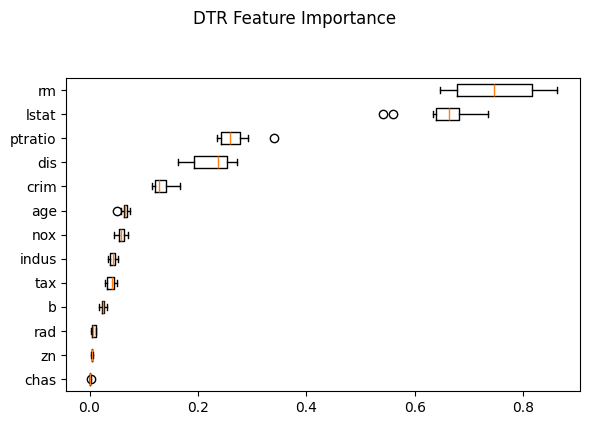

In [ ]:
from sklearn.inspection import permutation_importance

# let's make this repeatable! all you need to do is assign
# a model object to clf!

clf = DTR

result = permutation_importance(clf, X_train, y_train, n_repeats=10,
                                random_state=42)
perm_sorted_idx = result.importances_mean.argsort()

fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))
ax1.boxplot(result.importances[perm_sorted_idx].T, vert=False,
            labels=X.columns[perm_sorted_idx])
fig.suptitle('DTR Feature Importance', y=1.05)
fig.tight_layout()
plt.show()

**Figure 5:** Feature importance for DTR model.

### LR

/tmp/ipython-input-2637646068.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(result.importances[perm_sorted_idx].T, vert=False,


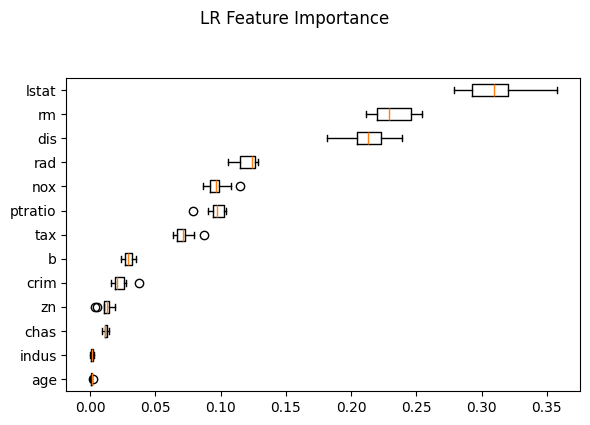

In [ ]:
# it even works for a linear regression!

from sklearn.inspection import permutation_importance

# let's make this repeatable! all you need to do is assign
# a model object to clf!

clf = LR # don't forget to update title!

result = permutation_importance(clf, X_train, y_train, n_repeats=10,
                                random_state=42)
perm_sorted_idx = result.importances_mean.argsort()

fig, ax1 = plt.subplots(1, 1, figsize=(6, 4))
ax1.boxplot(result.importances[perm_sorted_idx].T, vert=False,
            labels=X.columns[perm_sorted_idx])
fig.suptitle('LR Feature Importance', y=1.05) # don't forget to update title!
fig.tight_layout()
plt.show()

**Figure 6:** Feature importance for LR model.

### Side By Side! As a boxplot.
Note how different variables are important - look at the Y axis!

Here is how to set a subplot title: https://matplotlib.org/3.1.1/gallery/subplots_axes_and_figures/subplots_demo.html

`ax1.set_title('Axis 1')`

Remember, the scale of the X axis doesn't matter as much... you are looking for general trends.... which variables are the most important across your models?

/tmp/ipython-input-1046699164.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(result.importances[perm_sorted_idx].T, vert=False,
/tmp/ipython-input-1046699164.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(result.importances[perm_sorted_idx].T, vert=False,
/tmp/ipython-input-1046699164.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax3.boxplot(result.importances[perm_sorted_idx].T, vert=False,


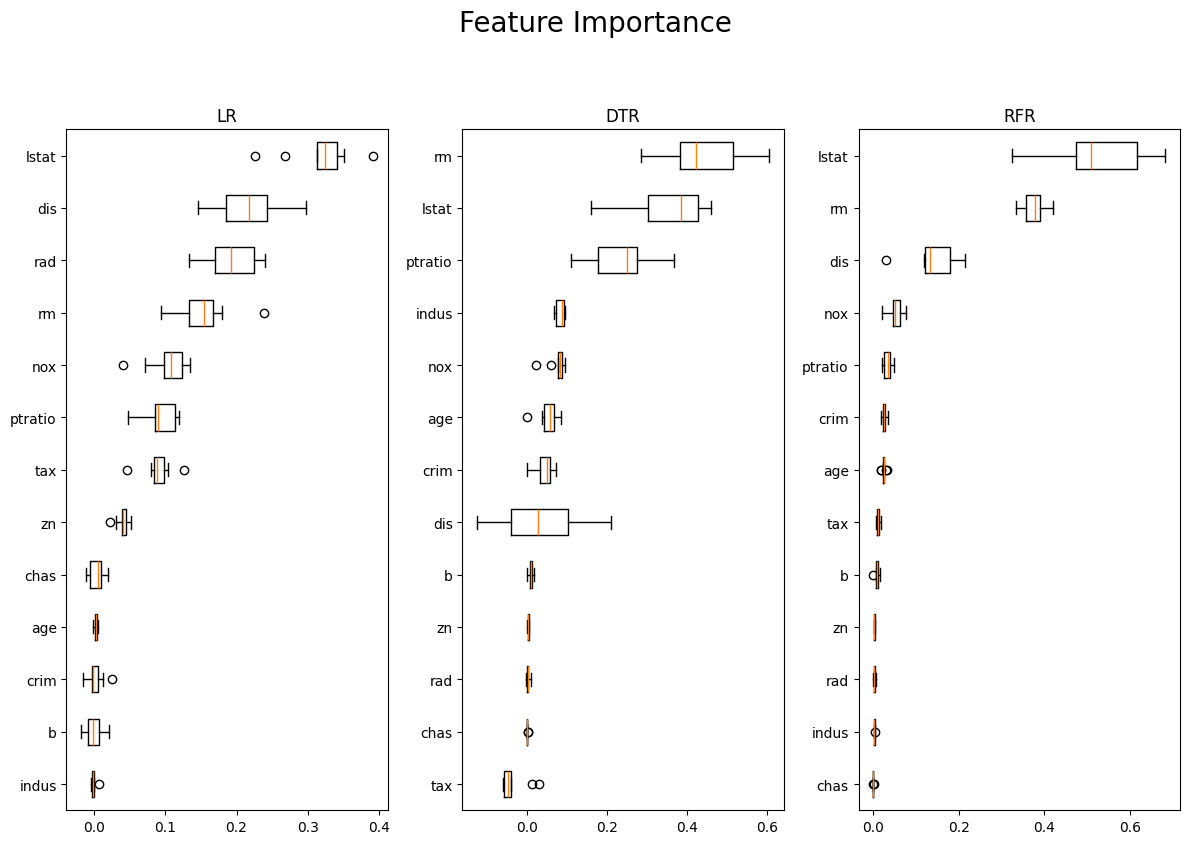

In [ ]:
# plot basics
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 8)) # 1 row, 3 columns
plt.suptitle('Feature Importance', y= 1.05, size = 20)
# LR
clf = LR # don't forget to update title!
result = permutation_importance(clf, X_test, y_test, n_repeats=10,
                                random_state=42)
perm_sorted_idx = result.importances_mean.argsort()
ax1.boxplot(result.importances[perm_sorted_idx].T, vert=False,
            labels=X.columns[perm_sorted_idx])
ax1.set_title('LR')

# DTR
clf = DTR # don't forget to update title!
result = permutation_importance(clf, X_test, y_test, n_repeats=10,
                                random_state=42)
perm_sorted_idx = result.importances_mean.argsort()

ax2.boxplot(result.importances[perm_sorted_idx].T, vert=False,
            labels=X.columns[perm_sorted_idx])
ax2.set_title('DTR')

# RFR
clf = RFR # don't forget to update title!
result = permutation_importance(clf, X_test, y_test, n_repeats=10,
                                random_state=42)
perm_sorted_idx = result.importances_mean.argsort()

ax3.boxplot(result.importances[perm_sorted_idx].T, vert=False,
            labels=X.columns[perm_sorted_idx])
ax3.set_title('RFR')

fig.tight_layout()
plt.show()

**Figure 7:** Feature importance for all models as multipanel plot.

# 🔴 ICE and PDP Plots
Whereas feature importance was shown on test, we will use ICE and PDP on the train partition. You can do either - you are just telling a different story.

In [ ]:
# pcyebox likes the data to be in a DataFrame so let's create one with our imputed data
# we first need to impute the missing data
train_X_df = pd.DataFrame(X_train, columns=X.columns)
train_X_df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.168763,0.00,0.642963,0.0,0.471193,0.293065,0.972194,0.088307,1.000000,0.914122,0.808511,0.880428,0.639625
1,0.006950,0.00,0.274074,0.0,0.314815,0.400854,0.552008,0.306359,0.130435,0.229008,0.893617,0.996772,0.185982
2,0.000288,0.35,0.197037,0.0,0.108848,0.440919,0.210093,0.501150,0.000000,0.223282,0.457447,0.912628,0.168322
3,0.079146,0.00,0.642963,0.0,0.471193,0.455562,0.846550,0.081132,1.000000,0.914122,0.808511,0.005547,0.594923
4,0.008056,0.00,0.274074,0.0,0.314815,0.379093,0.685891,0.242514,0.130435,0.229008,0.893617,0.984997,0.263521


In [ ]:
train_X_df.shape

(404, 13)

In [ ]:
train_X_df['lstat'].nunique()

370

# How does it work?
* There are 370 unique values in the `lstat` column. Make one row for each unique value.
* Now, each row in `X_train` is going to "try out" how the model would predict if it had that unique value of `lstat`. So for each unique value in `lstat`, you will evaluate the model 404 times (since there are 404 rows in `X_train`). This means you can plot how


### RFR
Just testing the waters with the RFR model...

Notice that ICE is looking at EACH OBSERVATION, vs. PDP which is the average across all ICE curves.

BTW - if you change RFR.predict to DTR.predict or LR.predict, you can see how each model treats the data.

#### lstat

In [ ]:
tmpdf = ice(data=train_X_df, # ice needs a dataframe
            column='lstat', # the column name
                   predict=RFR.predict) # the predict statement from the
                                          # model
print(np.shape(tmpdf))

(370, 404)


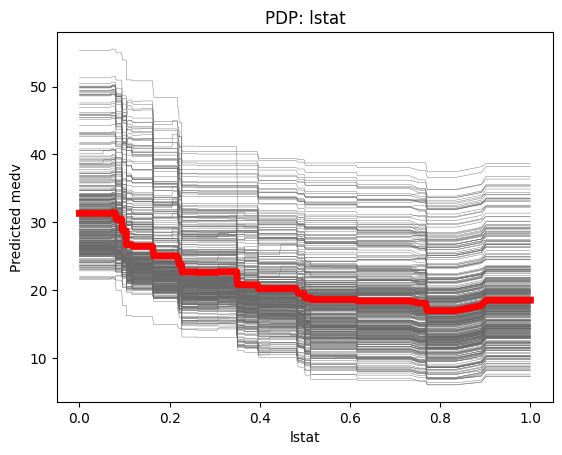

In [ ]:
ice_plot(tmpdf, c='dimgray', linewidth=0.3,
                  plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color':'red'})
plt.title('PDP: lstat')
plt.ylabel('Predicted medv')
plt.xlabel('lstat');
plt.show()

**Figure 8:** Partial dependence plot for lstat - red line is the PDP curve (average of ICE curves), gray lines are the ICE curves.

In [ ]:
tmpdf

data_lstat   0.000000   0.005243   0.006898   0.020419   0.031457   0.033389  \
crim         0.016346   0.020510   0.000276   0.006364   0.000872   0.000262   
zn              0.000      0.000      0.750      0.000      0.450      0.000   
indus        0.697778   0.697778   0.081852   0.202222   0.100000   0.053333   
chas              0.0        1.0        0.0        0.0        0.0        0.0   
nox          0.452675   0.452675   0.088477   0.251029   0.106996   0.150206   
rm           0.737442   0.801098   0.642872   0.909904   0.674192   0.637584   
age          0.905252   0.981462   0.132853   0.725026   0.240989   0.441813   
dis          0.076503   0.082851   0.388428   0.246324   0.486519   0.448545   
rad          0.173913   0.173913   0.086957   0.304348   0.173913   0.086957   
tax          0.412214   0.412214   0.124046   0.229008   0.402672   0.066794   
ptratio      0.223404   0.223404   0.606383   0.510638   0.276596   0.648936   
b            0.943341   0.981618   0.996772   0.972288   0.983837   0.994276   
lstat                                                                          
0.000000    49.389964  49.923627  33.329258  42.880240  35.842066  34.034600   
0.005243    49.389964  49.923627  33.329258  42.880240  35.842066  34.034600   
0.006898    49.389964  49.923627  33.329258  42.880240  35.842066  34.034600   
0.020419    49.389964  49.923627  33.329258  42.880240  35.842066  34.034600   
0.031457    49.389964  49.923627  33.329258  42.880240  35.842066  34.034600   
..                ...        ...        ...        ...        ...        ...   
0.834989    29.777928  30.864230  25.597593  32.005107  28.027918  24.846182   
0.891004    30.516971  31.603273  26.336636  32.744150  28.766961  25.585225   
0.901766    31.358245  32.444548  26.791402  33.585424  29.221726  26.758729   
0.911700    31.358245  32.444548  26.791402  33.585424  29.221726  26.758729   
1.000000    31.358245  32.444548  26.791402  33.585424  29.221726  26.758729   

data_lstat   0.033940   0.034492   0.035320   0.038079  ...   0.778146  \
crim         0.073395   0.000978   0.000587   0.000071  ...   0.002273   
zn              0.000      0.400      0.200      0.900  ...      0.125   
indus        0.642963   0.210000   0.095926   0.111481  ...   0.264074   
chas              1.0        0.0        1.0        0.0  ...        0.0   
nox          0.506173   0.127572   0.119136   0.018519  ...   0.286008   
rm           0.641245   0.608298   0.769168   0.730323  ...   0.359569   
age          0.974253   0.410917   0.481977   0.322348  ...   1.000000   
dis          0.006620   0.285326   0.371223   0.473452  ...   0.450354   
rad          1.000000   0.130435   0.173913   0.086957  ...   0.173913   
tax          0.914122   0.127863   0.055344   0.108779  ...   0.236641   
ptratio      0.808511   0.531915   0.244681   0.351064  ...   0.276596   
b            0.987770   1.000000   0.949997   0.973372  ...   0.974104   
lstat                                                   ...              
0.000000    48.641211  32.861212  45.819331  42.918111  ...  25.848161   
0.005243    48.641211  32.861212  45.819331  42.918111  ...  25.848161   
0.006898    48.641211  32.861212  45.819331  42.918111  ...  25.848161   
0.020419    48.641211  32.861212  45.819331  42.918111  ...  25.848161   
0.031457    48.641211  32.861212  45.819331  42.918111  ...  25.848161   
..                ...        ...        ...        ...  ...        ...   
0.834989    21.121181  23.780401  32.997024  32.104115  ...  16.765448   
0.891004    21.860223  24.519444  33.736066  32.843158  ...  17.504490   
0.901766    22.701498  24.974210  34.909570  33.297924  ...  18.345765   
0.911700    22.701498  24.974210  34.909570  33.297924  ...  18.345765   
1.000000    22.701498  24.974210  34.909570  33.297924  ...  18.345765   

data_lstat   0.779249   0.797461   0.802428              0.834989   0.891004  \
crim         0.111361   0.225655   0.002752   0.188865   0.253892   

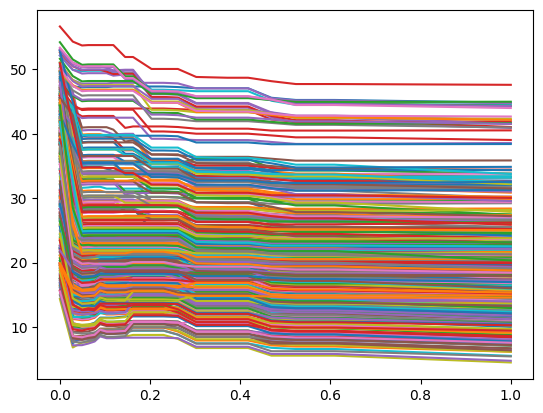

In [ ]:
# see if you can recreate the output!
# there should be 404 curves on this plot!
# one for each curve in X_train :)
plt.plot(tmpdf)
plt.show()

**Figure 9:** ICE curves for LSTAT.

In [ ]:
# you can try to hack the code if you want
# but it is a little hard to see
tmpdf

data_lstat   0.000000   0.005243   0.006898   0.020419   0.031457   0.033389  \
crim         0.016346   0.020510   0.000276   0.006364   0.000872   0.000262   
zn              0.000      0.000      0.750      0.000      0.450      0.000   
indus        0.697778   0.697778   0.081852   0.202222   0.100000   0.053333   
chas              0.0        1.0        0.0        0.0        0.0        0.0   
nox          0.452675   0.452675   0.088477   0.251029   0.106996   0.150206   
rm           0.737442   0.801098   0.642872   0.909904   0.674192   0.637584   
age          0.905252   0.981462   0.132853   0.725026   0.240989   0.441813   
dis          0.076503   0.082851   0.388428   0.246324   0.486519   0.448545   
rad          0.173913   0.173913   0.086957   0.304348   0.173913   0.086957   
tax          0.412214   0.412214   0.124046   0.229008   0.402672   0.066794   
ptratio      0.223404   0.223404   0.606383   0.510638   0.276596   0.648936   
b            0.943341   0.981618   0.996772   0.972288   0.983837   0.994276   
lstat                                                                          
0.000000    49.389964  49.923627  33.329258  42.880240  35.842066  34.034600   
0.005243    49.389964  49.923627  33.329258  42.880240  35.842066  34.034600   
0.006898    49.389964  49.923627  33.329258  42.880240  35.842066  34.034600   
0.020419    49.389964  49.923627  33.329258  42.880240  35.842066  34.034600   
0.031457    49.389964  49.923627  33.329258  42.880240  35.842066  34.034600   
..                ...        ...        ...        ...        ...        ...   
0.834989    29.777928  30.864230  25.597593  32.005107  28.027918  24.846182   
0.891004    30.516971  31.603273  26.336636  32.744150  28.766961  25.585225   
0.901766    31.358245  32.444548  26.791402  33.585424  29.221726  26.758729   
0.911700    31.358245  32.444548  26.791402  33.585424  29.221726  26.758729   
1.000000    31.358245  32.444548  26.791402  33.585424  29.221726  26.758729   

data_lstat   0.033940   0.034492   0.035320   0.038079  ...   0.778146  \
crim         0.073395   0.000978   0.000587   0.000071  ...   0.002273   
zn              0.000      0.400      0.200      0.900  ...      0.125   
indus        0.642963   0.210000   0.095926   0.111481  ...   0.264074   
chas              1.0        0.0        1.0        0.0  ...        0.0   
nox          0.506173   0.127572   0.119136   0.018519  ...   0.286008   
rm           0.641245   0.608298   0.769168   0.730323  ...   0.359569   
age          0.974253   0.410917   0.481977   0.322348  ...   1.000000   
dis          0.006620   0.285326   0.371223   0.473452  ...   0.450354   
rad          1.000000   0.130435   0.173913   0.086957  ...   0.173913   
tax          0.914122   0.127863   0.055344   0.108779  ...   0.236641   
ptratio      0.808511   0.531915   0.244681   0.351064  ...   0.276596   
b            0.987770   1.000000   0.949997   0.973372  ...   0.974104   
lstat                                                   ...              
0.000000    48.641211  32.861212  45.819331  42.918111  ...  25.848161   
0.005243    48.641211  32.861212  45.819331  42.918111  ...  25.848161   
0.006898    48.641211  32.861212  45.819331  42.918111  ...  25.848161   
0.020419    48.641211  32.861212  45.819331  42.918111  ...  25.848161   
0.031457    48.641211  32.861212  45.819331  42.918111  ...  25.848161   
..                ...        ...        ...        ...  ...        ...   
0.834989    21.121181  23.780401  32.997024  32.104115  ...  16.765448   
0.891004    21.860223  24.519444  33.736066  32.843158  ...  17.504490   
0.901766    22.701498  24.974210  34.909570  33.297924  ...  18.345765   
0.911700    22.701498  24.974210  34.909570  33.297924  ...  18.345765   
1.000000    22.701498  24.974210  34.909570  33.297924  ...  18.345765   

data_lstat   0.779249   0.797461   0.802428              0.834989   0.891004  \
crim         0.111361   0.225655   0.002752   0.188865   0.253892   

#### crim

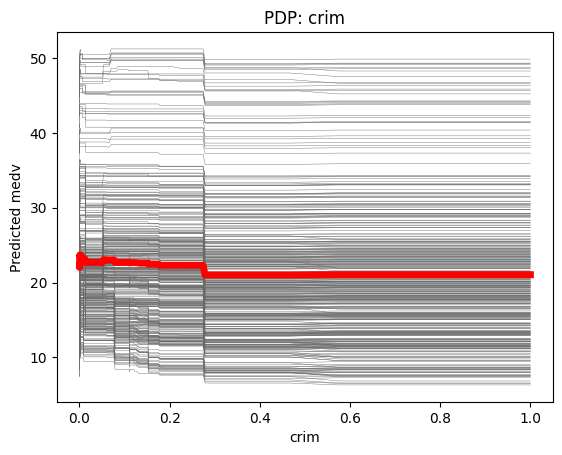

In [ ]:
tmpdf = ice(data=train_X_df, column='crim',
                   predict=RFR.predict)

ice_plot(tmpdf, c='dimgray', linewidth=0.3,
                  plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color':'red'})
plt.title('PDP: crim')
plt.ylabel('Predicted medv')
plt.xlabel('crim');
plt.show()

**Figure 10:** Partial dependence plot for crim - red line is the PDP curve (average of ICE curves), gray lines are the ICE curves.

#### dis

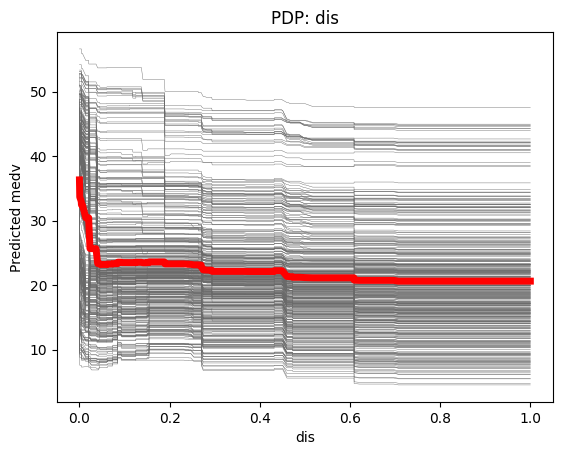

In [ ]:
tmpdf = ice(data=train_X_df, column='dis',
                   predict=RFR.predict)

ice_plot(tmpdf, c='dimgray', linewidth=0.3,
                  plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color':'red'})
plt.title('PDP: dis')
plt.ylabel('Predicted medv')
plt.xlabel('dis');
plt.show()

**Figure 10:** Partial dependence plot for `dis` - red line is the PDP curve (average of ICE curves), gray lines are the ICE curves.

### **[new!]** A 'clunkier' PDP with num_grid_points

This one has num_grid_points = 10...

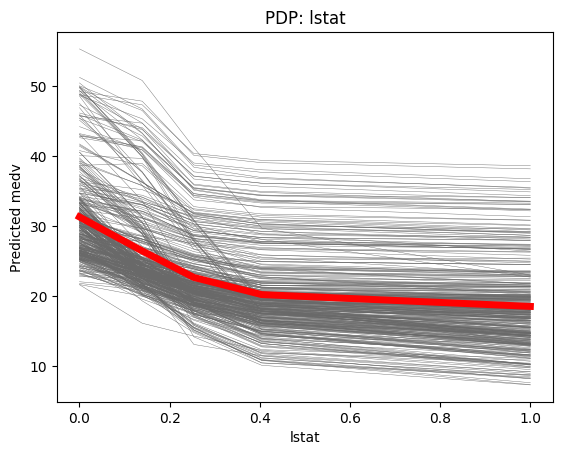

In [ ]:
tmpdf = ice(data=train_X_df, column='lstat',
                   predict=RFR.predict,
            num_grid_points=5)

ice_plot(tmpdf, c='dimgray', linewidth=0.3,
                  plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color':'red'})
plt.title('PDP: lstat')
plt.ylabel('Predicted medv')
plt.xlabel('lstat');
plt.show()

**Figure 11:** Partial dependence plot for lstat - red line is the PDP curve (average of ICE curves), gray lines are the ICE curves. Used the num_grid_points argument.

This one has num_grid_points = 20... feel free to use either for your project!

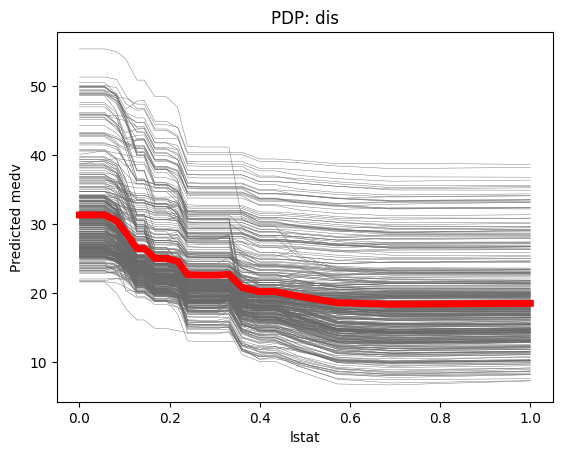

In [ ]:
tmpdf = ice(data=train_X_df, column='lstat',
                   predict=RFR.predict,
            num_grid_points=20)

ice_plot(tmpdf, c='dimgray', linewidth=0.3,
                  plot_pdp=True,
         pdp_kwargs={'linewidth': 5, 'color':'red'})
plt.title('PDP: dis')
plt.ylabel('Predicted medv')
plt.xlabel('lstat');
plt.show()

**Figure 12:** Partial dependence plot for dis - red line is the PDP curve (average of ICE curves), gray lines are the ICE curves. Used the num_grid_points argument.

### Side by Side! More info at once.
It's nice to see all of this as subplots, tell a story all at once for the top three variables.

I stole this (!) from the bottom of this webpage, and updated it: http://savvastjortjoglou.com/intrepretable-machine-learning-nfl-combine.html

Be efficient - find code that does what you need it to do, and then try to understand what's going on.

Note that this plot shows the first nrows*ncols columns in the df - if you want more (or have more columns than 9, the default) you will need to change the shape!

In [ ]:
def plot_ice_grid(dict_of_ice_dfs, data_df, features, ax_ylabel='', nrows=4,
                  ncols=4, figsize=(12, 12), sharex=False, sharey=True,
                  num_grid_points = 10, # DW added this on 4/27/2022!
                  subplots_kws={}, rug_kws={'color':'k'}, **ice_plot_kws):
    """A function that plots ICE plots for different features in a grid."""
    fig, axes = plt.subplots(nrows=nrows,
                             ncols=ncols,
                             figsize=figsize,
                             sharex=sharex,
                             sharey=sharey,
                             **subplots_kws)
    # for each feature plot the ice curves and add a rug at the bottom of the
    # subplot
    for f, ax in zip(features, axes.flatten()):
        ice_plot(dict_of_ice_dfs[f], ax=ax, **ice_plot_kws)
        # add the rug
        sns.distplot(data_df[f], ax=ax, hist=False, kde=False,
                     rug=True, rug_kws=rug_kws)
        ax.set_title('feature = ' + f)
        ax.set_ylabel(ax_ylabel)
        sns.despine()

    # get rid of blank plots
    for i in range(len(features), nrows*ncols):
        axes.flatten()[i].axis('off')

    return fig

In [ ]:
train_X_df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat
0,0.168763,0.00,0.642963,0.0,0.471193,0.293065,0.972194,0.088307,1.000000,0.914122,0.808511,0.880428,0.639625
1,0.006950,0.00,0.274074,0.0,0.314815,0.400854,0.552008,0.306359,0.130435,0.229008,0.893617,0.996772,0.185982
2,0.000288,0.35,0.197037,0.0,0.108848,0.440919,0.210093,0.501150,0.000000,0.223282,0.457447,0.912628,0.168322
3,0.079146,0.00,0.642963,0.0,0.471193,0.455562,0.846550,0.081132,1.000000,0.914122,0.808511,0.005547,0.594923
4,0.008056,0.00,0.274074,0.0,0.314815,0.379093,0.685891,0.242514,0.130435,0.229008,0.893617,0.984997,0.263521


/tmp/ipython-input-2234343428.py:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_df[f], ax=ax, hist=False, kde=False,
/tmp/ipython-input-2234343428.py:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_df[f], ax=ax, hist=False, kde=False,
/tmp/ipython-input-2234343428.py:17: UserWarni

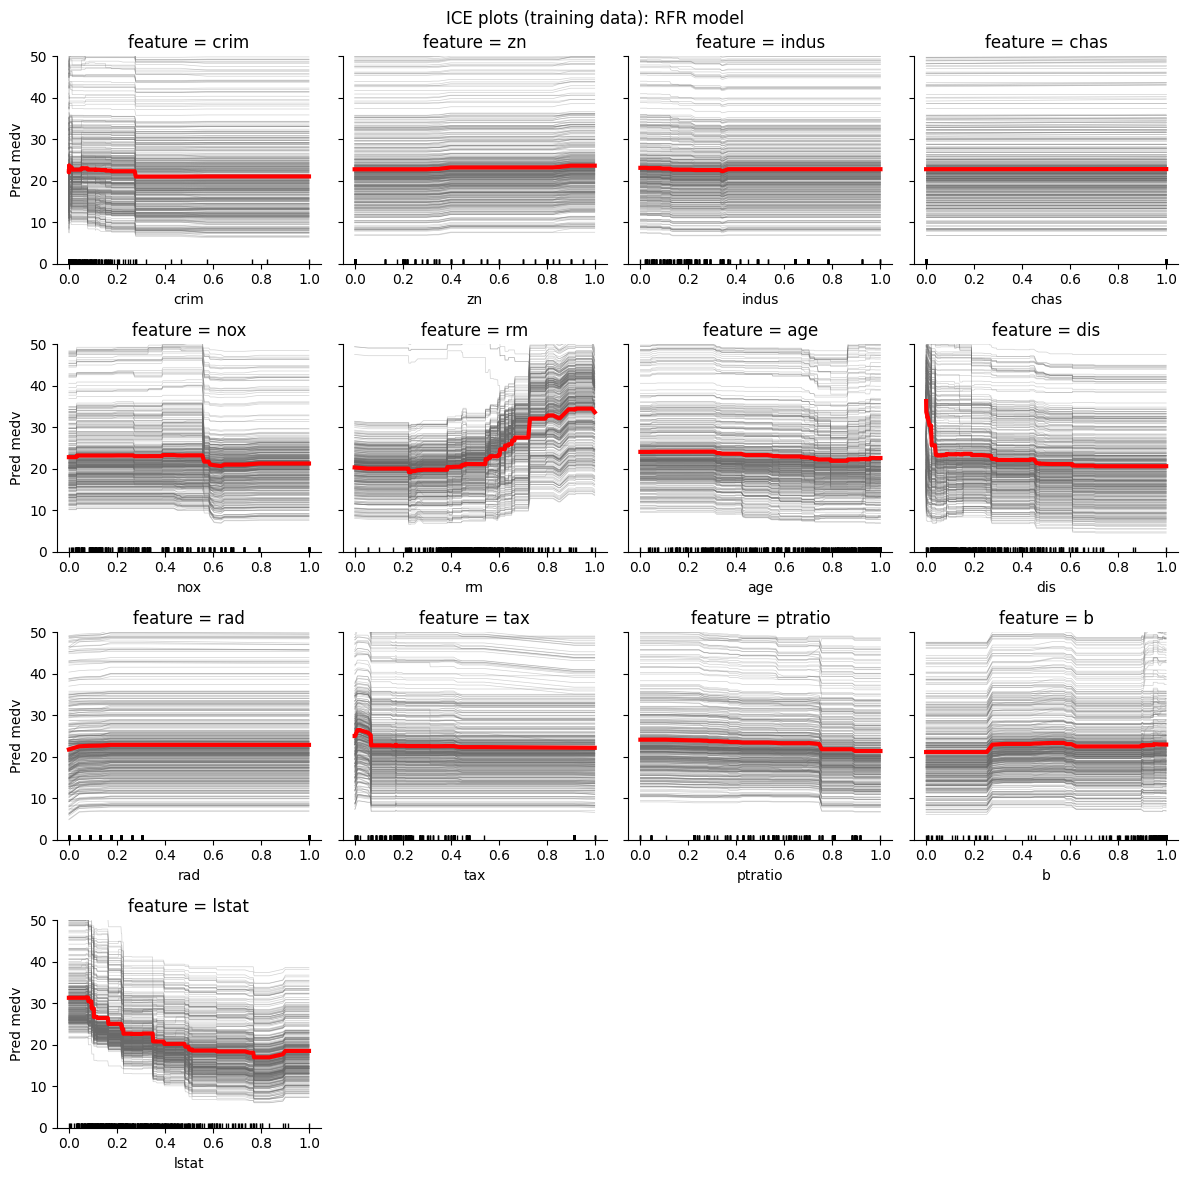

In [ ]:
# columns to plot
features = train_X_df.columns

# create dict of ICE data for grid of ICE plots
train_ice_dfs = {feat: ice(data=train_X_df, column=feat, predict=RFR.predict)
                 for feat in features}

plot_ice_grid(train_ice_dfs, train_X_df, features,
                    ax_ylabel='Pred medv', alpha=0.3, plot_pdp=True,
                    pdp_kwargs={'c': 'red', 'linewidth': 3},
                    linewidth=0.5, c='dimgray')
plt.ylim([0,50])
plt.suptitle('ICE plots (training data): RFR model')
plt.subplots_adjust(top=0.89)
plt.tight_layout()

**Figure 13:** Partial dependence plot matrix for all covariates.

# Done!

Wow. Now, not only can you fit any sklearn ML model - you can start to tease out which variables are most important, and then can try to show **how the models treat the data**. Amazing.




# Resources
Here are some great links (the text is good, but the code is in R):
* Partial Dependence Plots (PDP): [link from an excellent ML interpretability book for PDPs](https://christophm.github.io/interpretable-ml-book/pdp.html)
* Individual Conditional Expectation (ICE): [link from an excellent ML interpretability book for ICE](https://christophm.github.io/interpretable-ml-book/ice.html#ice)

Nice example using PYCEbox (students are welcome to use the sklearn interpretation)
* [PYCEbox documentation](http://austinrochford.github.io/PyCEbox/docs/)

# [optional] Bonus Time! PDPs for Linear Regression...
Let's see how a linear regression does...

/tmp/ipython-input-2234343428.py:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_df[f], ax=ax, hist=False, kde=False,
/tmp/ipython-input-2234343428.py:17: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_df[f], ax=ax, hist=False, kde=False,
/tmp/ipython-input-2234343428.py:17: UserWarni

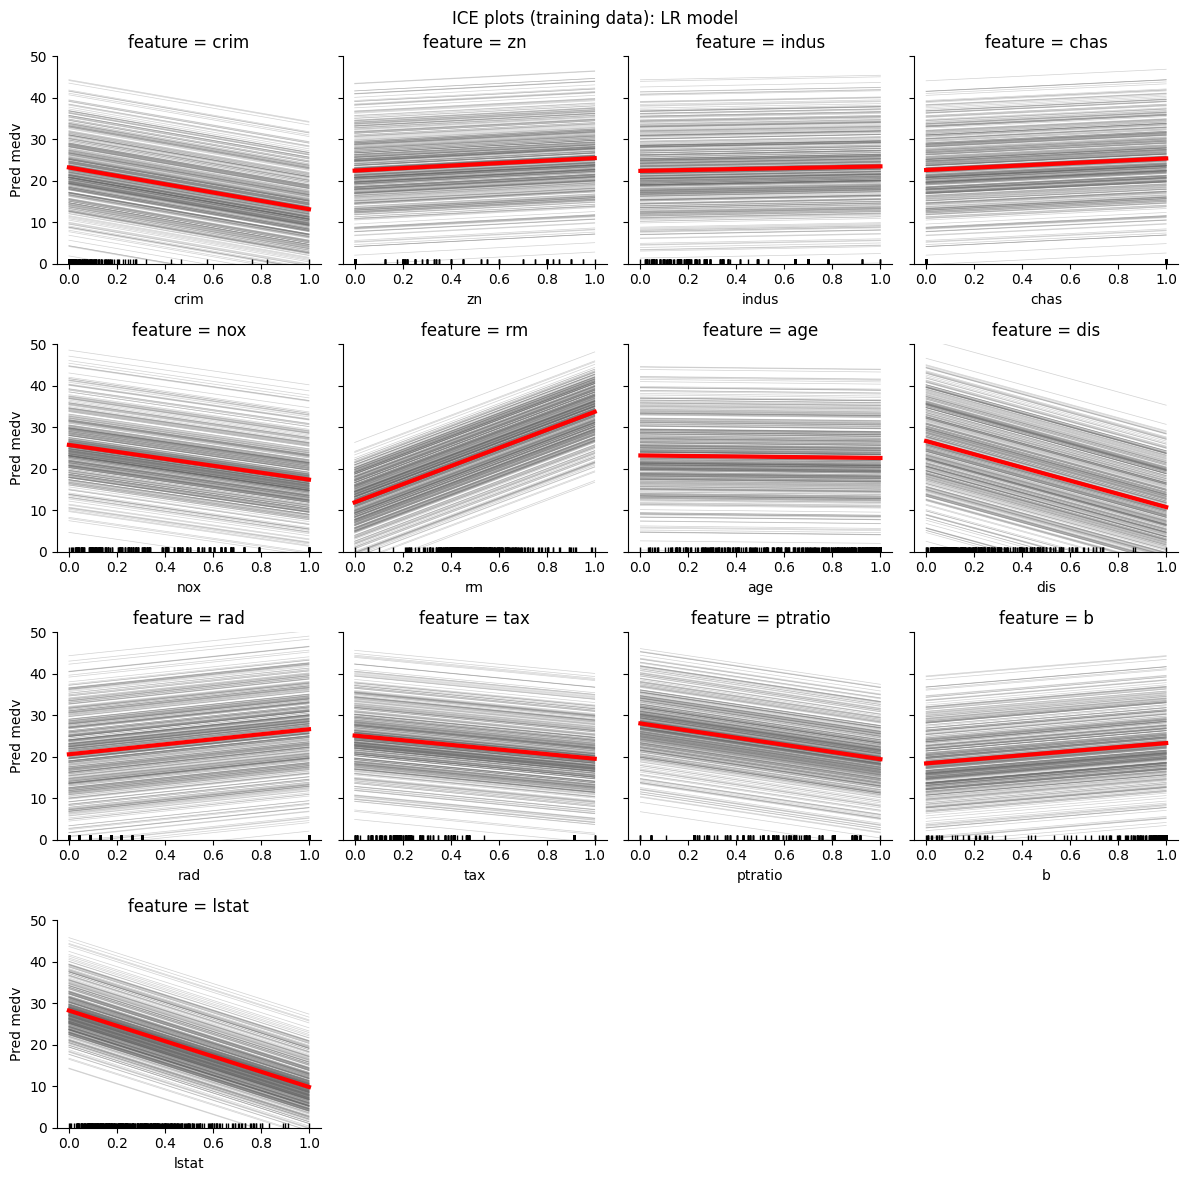

In [ ]:
# columns to plot
features = train_X_df.columns

# create dict of ICE data for grid of ICE plots
train_ice_dfs = {feat: ice(data=train_X_df, column=feat, predict=LR.predict) # change predict = LR.predict or RFR.predict or DTR.predict
                 for feat in features}

plot_ice_grid(train_ice_dfs, train_X_df, features,
                    ax_ylabel='Pred medv', alpha=0.3, plot_pdp=True,
                    pdp_kwargs={'c': 'red', 'linewidth': 3},
                    linewidth=0.5, c='dimgray')
plt.ylim([0,50])
plt.suptitle('ICE plots (training data): LR model')
plt.subplots_adjust(top=0.89)
plt.tight_layout()

**Figure 14:** Linear model PDPs that shows a linear fitted relationship between input and output - makes sense!